In [11]:
import pandas as pd 

data = pd.read_csv("ionosphere.csv", header=None)
data.iloc[:, -1].value_counts()

34
g    225
b    126
Name: count, dtype: int64

## KL-Inversion

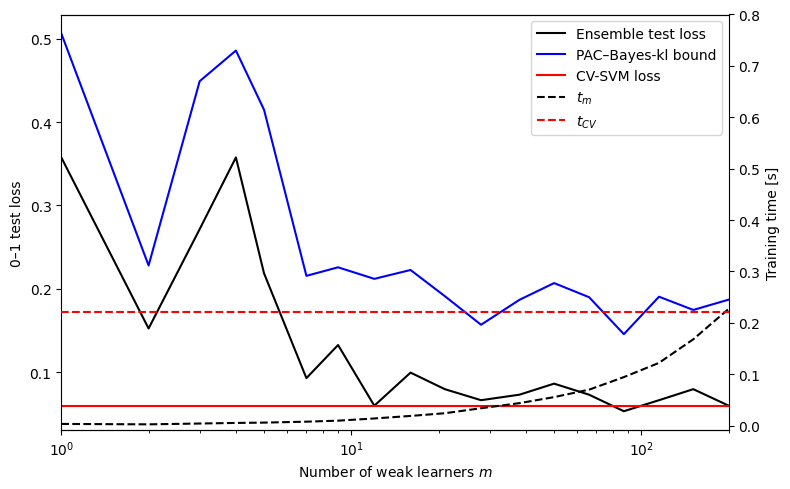

In [96]:
import time
import math
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.svm import SVC
from sklearn.metrics import zero_one_loss
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

#  Configuration
RANDOM_STATE = 3 # 3 is the best
TRAIN_SIZE   = 200      # follow Thiemann et al.: n=200 train, rest test
DELTA        = 0.05
MAX_ITERS    = 200
TOL          = 1e-6

#  Load & preprocess Ionosphere
df     = pd.read_csv("ionosphere.csv", header=None)
X_raw  = df.iloc[:,:-1].values.astype(float)
y_raw  = np.where(df.iloc[:,-1]=="g", 1, -1)

# 200 train / 151 test split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y_raw,
    train_size=TRAIN_SIZE,
    stratify=y_raw,
    random_state=RANDOM_STATE
)
scaler   = StandardScaler().fit(X_tr)     # feature scaling
X_train  = scaler.transform(X_tr)
X_test   = scaler.transform(X_te)
n, d     = X_train.shape
R        = d + 1
n_r      = n - R

# Compute Jaakkola γ grid
def jaakkola_gamma(X, y):
    mask  = y[:,None] != y[None,:]
    dists = np.linalg.norm(X[:,None,:] - X[None,:,:], axis=2)[mask]
    return 1.0 / (2.0 * np.median(dists)**2)

gamma_J    = jaakkola_gamma(X_train, y_tr)
gamma_grid = gamma_J * 10.0 ** np.arange(-4, 5)

#  Baseline: CV-tuned RBF SVM on full 200-point train
param_grid = {"C": 10.0**np.arange(-3,4), "gamma": gamma_grid}
cv = GridSearchCV(
    SVC(kernel="rbf"),                        # scikit-learn’s SVC (LIBSVM)
    param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1
)
t0 = time.time()
cv.fit(X_train, y_tr)
t_cv    = time.time() - t0
cv_loss = zero_one_loss(y_te, cv.predict(X_test))

# PAC-Bayes helper functions 
def kl_divergence(p, q):
    if p == 0: term1 = 0.0
    else:      term1 = p * math.log(p/q)
    if p == 1: term2 = 0.0
    else:      term2 = (1-p) * math.log((1-p)/(1-q))
    return term1 + term2

def kl_inverse(p_hat, kl_term, n):
    if p_hat >= 1.0: return 1.0
    target = kl_term / n
    lo, hi  = p_hat, 1.0
    while hi - lo > 1e-12:
        mid = 0.5*(lo+hi)
        if kl_divergence(p_hat, mid) > target:
            hi = mid
        else:
            lo = mid
    return lo

def pacbayes_rho(val_losses, lam, n_r):
    shift = val_losses.min()
    w     = np.exp(-lam * n_r * (val_losses - shift))
    return w / w.sum()

def pacbayes_lambda(E_val, kl_rho, n_r, delta=DELTA):
    num = 2.0 * n_r * E_val
    den = kl_rho + math.log(2.0 * math.sqrt(n_r) / delta)
    return 2.0 / (math.sqrt(1.0 + num/den) + 1.0)

# Hypothesis-set sizes
raw_grid = np.logspace(0, math.log10(n), 20)
M_VALUES = np.unique(np.round(raw_grid).astype(int))

# Single-seed PAC-Bayes sweep 
rng = np.random.default_rng(RANDOM_STATE)
results = []
for m in M_VALUES:
    t_start = time.time()
    pi      = np.full(m, 1.0/m)

    # train m weak SVMs on random subsets
    val_losses = np.zeros(m)
    models     = []
    for i in range(m):
        idx_tr = rng.choice(n, size=R, replace=False)
        idx_va = np.setdiff1d(np.arange(n), idx_tr)
        clf    = SVC(kernel="rbf", C=1.0,
                     gamma=float(rng.choice(gamma_grid)))
        clf.fit(X_train[idx_tr], y_tr[idx_tr])
        models.append(clf)
        val_losses[i] = zero_one_loss(
            y_tr[idx_va],
            clf.predict(X_train[idx_va])
        )

    # alternate minimisation of PAC-Bayes–λ bound
    lam = max(1.0/math.sqrt(n_r), 0.5)
    for _ in range(MAX_ITERS):
        rho    = pacbayes_rho(val_losses, lam, n_r)
        E_val  = float(rho.dot(val_losses))
        kl_rho = float((rho * np.log(rho/pi)).sum())
        lam_n  = pacbayes_lambda(E_val, kl_rho, n_r)
        if abs(lam_n - lam) < TOL:
            lam = lam_n
            break
        lam = lam_n

    # ρ-weighted majority-vote test loss
    preds     = np.vstack([clf.predict(X_test) for clf in models]).T
    vote      = np.sign(preds.dot(rho))
    test_loss = zero_one_loss(y_te, vote)

    # exact PAC-Bayes-kl bound
    kl_term = kl_rho + math.log(2.0 * math.sqrt(n_r) / DELTA)
    bound   = kl_inverse(E_val, kl_term, n_r)

    results.append((m, test_loss, bound, time.time() - t_start))

# ─── Plot ────────────────────────────────────────────────────────────── #
ms, test_losses, kl_bounds, times = zip(*results)

fig, ax1 = plt.subplots(figsize=(8,5))

# --- Plot losses on ax1 (default left) ---
ax1.plot(ms, test_losses, 'k-', label='Ensemble test loss')
ax1.plot(ms, kl_bounds,   'b-', label='PAC–Bayes-kl bound')
ax1.axhline(cv_loss, color='r', linestyle='-', label='CV-SVM loss')
ax1.set_xscale('log')
ax1.set_xlim(min(ms), max(ms))
ax1.set_xlabel('Number of weak learners $m$')

# Ensure test-loss axis is on the left
ax1.yaxis.set_label_position("left")
ax1.yaxis.tick_left()
ax1.set_ylabel('0–1 test loss')
# (optional) hide the right spine if it’s empty:
ax1.spines['right'].set_visible(False)

# --- Create twin for timing, but on the right ---
ax2 = ax1.twinx()
ax2.plot(ms, times, 'k--', label='$t_m$')
ax2.axhline(t_cv, color='r', linestyle='--', label='$t_{CV}$')
# ax2.set_ylim(0.0, 0.8)
ax2.set_yticks(np.arange(0.0, 0.9, 0.1))
ax2.set_ylabel('Training time [s]')

# Make sure time axis is on the right
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
# (optional) hide the left spine for this twin so it doesn’t collide:
ax2.spines['left'].set_visible(False)

# --- Legend & finalize ---
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper right')

plt.tight_layout()
plt.savefig("ionosphere_pacbayes_single_seed.pdf", dpi=300)
plt.show()



## Optional

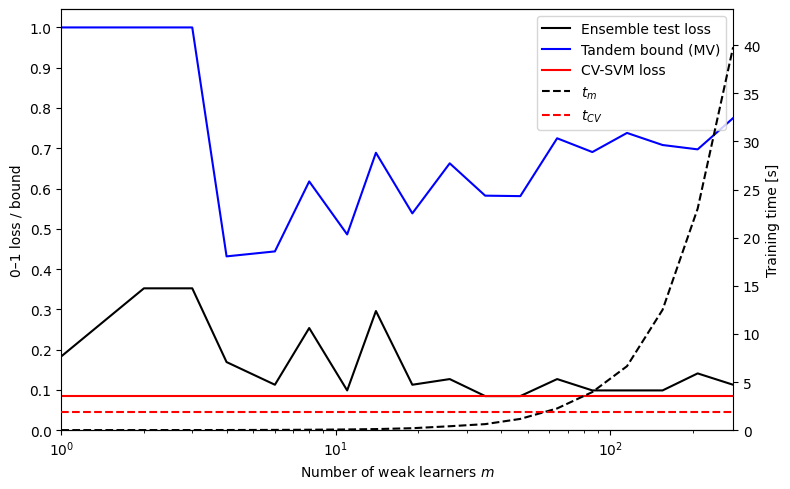

In [9]:
import time, math
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import zero_one_loss
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ───────── Config ───────── #
RANDOM_STATE = 0  # zero or 4 is best
TRAIN_SIZE   = 280
DELTA        = 0.05
MAX_ITERS    = 200
TOL          = 1e-6

# ─── Load & preprocess ───────────────────── #
df    = pd.read_csv("ionosphere.csv", header=None)
X_raw = df.iloc[:,:-1].values.astype(float)
y_raw = np.where(df.iloc[:,-1] == "g", 1, -1)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y_raw, train_size=TRAIN_SIZE,
    stratify=y_raw, random_state=RANDOM_STATE
)
scaler   = StandardScaler().fit(X_tr)
X_train  = scaler.transform(X_tr)
X_test   = scaler.transform(X_te)
n, d     = X_train.shape
R        = d + 1
n_r      = n - R

# ─── Jaakkola γ grid ───────────────────────── #
def jaakkola_gamma(X, y):
    mask  = y[:,None] != y[None,:]
    dists = np.linalg.norm(X[:,None,:] - X[None,:,:], axis=2)[mask]
    return 1.0 / (2.0 * np.median(dists)**2)

gamma_J    = jaakkola_gamma(X_train, y_tr)
gamma_grid = gamma_J * 10.0 ** np.arange(-4, 5)

# ─── Baseline CV‐SVM ───────────────────────── #
param_grid = {"C": 10.0**np.arange(-3, 4), "gamma": gamma_grid}
cv = GridSearchCV(
    SVC(kernel="rbf"), param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1
)
t0 = time.time()
cv.fit(X_train, y_tr)
t_cv    = time.time() - t0
cv_loss = zero_one_loss(y_te, cv.predict(X_test))

# ─── Helpers for tandem bound ───────────────── #
def pacbayes_rho(val_losses, lam):
    shift = val_losses.min()
    w     = np.exp(-lam * n_r * (val_losses - shift))
    return w / w.sum()

def pacbayes_lambda(E_val, kl_rho):
    num = 2.0 * n_r * E_val
    den = kl_rho + math.log(2.0 * math.sqrt(n_r) / DELTA)
    return 2.0 / (math.sqrt(1.0 + num/den) + 1.0)

# ─── Sweep over m ──────────────────────────── #
M_VALUES = np.unique(np.round(np.logspace(0, math.log10(n), 20)).astype(int))
records  = []
rng      = np.random.default_rng(RANDOM_STATE)

for m in M_VALUES:
    t_start = time.time()
    pi      = np.full(m, 1.0/m)

    # train m weak SVMs
    val_losses  = np.zeros(m)
    models      = []
    idx_va_list = []
    for i in range(m):
        idx_tr = rng.choice(n, size=R, replace=False)
        idx_va = np.setdiff1d(np.arange(n), idx_tr)
        idx_va_list.append(idx_va)
        clf = SVC(kernel="rbf", C=1.0, gamma=float(rng.choice(gamma_grid)))
        clf.fit(X_train[idx_tr], y_tr[idx_tr])
        models.append(clf)
        val_losses[i] = zero_one_loss(y_tr[idx_va], clf.predict(X_train[idx_va]))

    # alternate minimization of PB-λ bound to get ρ and λ
    lam = max(1.0/math.sqrt(n_r), 0.5)
    for _ in range(MAX_ITERS):
        rho    = pacbayes_rho(val_losses, lam)
        E_val  = float(rho.dot(val_losses))
        kl_rho = float((rho * np.log(rho/pi)).sum())
        lam_n  = pacbayes_lambda(E_val, kl_rho)
        if abs(lam_n - lam) < TOL:
            lam = lam_n
            break
        lam = lam_n

    # majority‐vote test loss
    preds   = np.vstack([clf.predict(X_test) for clf in models]).T
    mv_loss = zero_one_loss(y_te, np.sign(preds.dot(rho)))

    # tandem bound
    pair_losses = np.zeros((m, m))
    overlaps    = np.zeros((m, m), dtype=int)
    for i in range(m):
        for j in range(i+1, m):
            idx_int = np.intersect1d(idx_va_list[i], idx_va_list[j])
            overlaps[i,j] = overlaps[j,i] = len(idx_int)
            if len(idx_int) > 0:
                y_int = y_tr[idx_int]
                e_i   = models[i].predict(X_train[idx_int]) != y_int
                e_j   = models[j].predict(X_train[idx_int]) != y_int
                pair_losses[i,j] = pair_losses[j,i] = np.mean(e_i & e_j)
    off = overlaps[np.triu_indices(m, k=1)]
    if off.size and off.min() > 0:
        n2          = off.min()
        exp_tandem  = float(rho @ pair_losses @ rho)
        tandem_bnd  = 4 * (
            exp_tandem / (1 - lam/2)
            + (2*kl_rho + math.log(2.0*math.sqrt(n2)/DELTA))
              / (lam*(1 - lam/2)*n2)
        )
    else:
        tandem_bnd = 1.0

    # **Clip the bound to [0, 1] for plotting**
    tandem_bnd = min(tandem_bnd, 1.0)

    records.append((m, mv_loss, tandem_bnd, time.time() - t_start))

# ─── Plot ───────────────────────────────────── #
ms, mv_l, tan_b, times = zip(*records)
fig, ax1 = plt.subplots(figsize=(8,5))

# --- Left axis: loss curves ---
ax1.plot(ms, mv_l,  'k-',  label='Ensemble test loss')
ax1.plot(ms, tan_b, 'b-',  label='Tandem bound (MV)')
ax1.axhline(cv_loss, color='r', linestyle='-', label='CV-SVM loss')

ax1.set_xscale('log')
ax1.set_xlim(min(ms), max(ms))
ax1.margins(x=0)
ax1.set_yticks(np.linspace(0, 1, 11))
ax1.set_xlabel('Number of weak learners $m$')
ax1.set_ylabel('0–1 loss / bound')
ax1.yaxis.set_label_position("left")
ax1.yaxis.tick_left()
ax1.spines['right'].set_visible(False)

# --- Right axis: timing ---
ax2 = ax1.twinx()
ax2.plot(ms, times, 'k--', label='$t_m$')
ax2.axhline(t_cv, color='r', linestyle='--', label='$t_{CV}$')
ax2.set_ylim(0, max(times + (t_cv,)) * 1.1)
ax2.set_ylabel('Training time [s]')
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
ax2.spines['left'].set_visible(False)

# --- Unified legend ---
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper right')

plt.tight_layout()
plt.savefig("ionosphere_tandem_pacbayes.pdf", dpi=300)
plt.show()


## Across 10 runs

   m |     loss |  ±  |    bound |  ±  |  time[s] |  ± 
----------------------------------------------------------------------
   1 |   0.3364 | ± | 0.0573 |   0.4763 | ± | 0.0531 |     0.00 | ± |  0.00
   2 |   0.3225 | ± | 0.0715 |   0.4598 | ± | 0.0850 |     0.00 | ± |  0.00
   3 |   0.2781 | ± | 0.0956 |   0.4251 | ± | 0.0872 |     0.00 | ± |  0.00
   4 |   0.2146 | ± | 0.1239 |   0.3625 | ± | 0.1174 |     0.00 | ± |  0.00
   5 |   0.2126 | ± | 0.0965 |   0.3501 | ± | 0.1021 |     0.01 | ± |  0.00
   7 |   0.1742 | ± | 0.1015 |   0.3227 | ± | 0.1004 |     0.01 | ± |  0.00
   9 |   0.1225 | ± | 0.0509 |   0.2717 | ± | 0.0826 |     0.01 | ± |  0.00
  12 |   0.1113 | ± | 0.0891 |   0.2554 | ± | 0.0995 |     0.01 | ± |  0.00
  16 |   0.0848 | ± | 0.0273 |   0.2119 | ± | 0.0181 |     0.02 | ± |  0.00
  21 |   0.0927 | ± | 0.0242 |   0.2131 | ± | 0.0365 |     0.02 | ± |  0.00
  28 |   0.0801 | ± | 0.0152 |   0.1963 | ± | 0.0293 |     0.03 | ± |  0.00
  38 |   0.0801 | ± | 0.0155 |   0.19

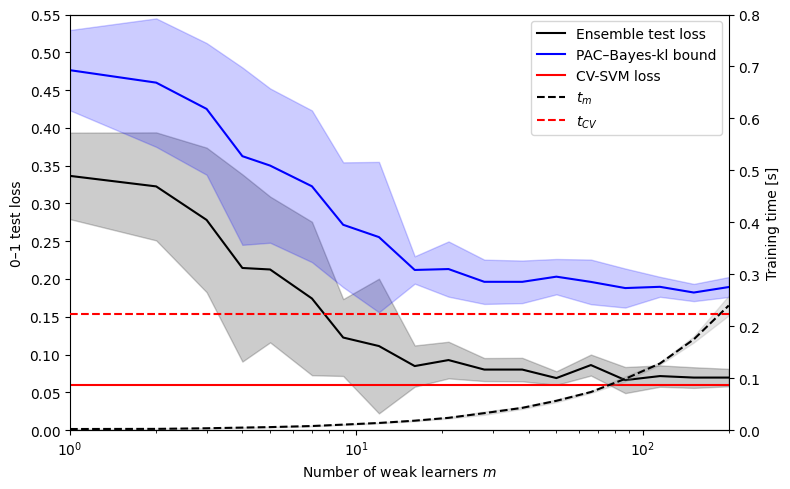

In [84]:
import time, math
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.svm import SVC
from sklearn.metrics import zero_one_loss
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler

# ────────── Configuration ────────── #
RANDOM_STATE = 3
TRAIN_SIZE   = 200      # follow Thiemann et al. by using n=200 train points
DELTA        = 0.05
MAX_ITERS    = 200
TOL          = 1e-6

# ─── Load & preprocess Ionosphere ──────────────────────────────────── #
df     = pd.read_csv("ionosphere.csv", header=None)
X_raw  = df.iloc[:,:-1].values.astype(float)
y_raw  = np.where(df.iloc[:,-1]=="g", 1, -1)

# fixed split: 200 train / 151 test
X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y_raw,
    train_size=TRAIN_SIZE,
    stratify=y_raw,
    random_state=RANDOM_STATE
)
scaler   = StandardScaler().fit(X_tr)            # scale features
X_train  = scaler.transform(X_tr)
X_test   = scaler.transform(X_te)
n, d     = X_train.shape
R        = d + 1
n_r      = n - R

# ─── Precompute γ grid (Jaakkola heuristic) ────────────────────────── #
def jaakkola_gamma(X, y):
    mask  = y[:,None] != y[None,:]
    dists = np.linalg.norm(X[:,None,:] - X[None,:,:], axis=2)[mask]
    return 1.0 / (2.0 * np.median(dists)**2)

gamma_J    = jaakkola_gamma(X_train, y_tr)
gamma_grid = gamma_J * 10.0 ** np.arange(-4, 5)

# ─── Baseline: CV‐tuned RBF SVM on full train set ───────────────────── #
param_grid = {"C": 10.0**np.arange(-3,4), "gamma": gamma_grid}
cv = GridSearchCV(
    SVC(kernel="rbf"),          # scikit‐learn’s SVC (wraps LIBSVM)
    param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1
)
t0 = time.time()
cv.fit(X_train, y_tr)
t_cv    = time.time() - t0
cv_loss = zero_one_loss(y_te, cv.predict(X_test))

# ─── PAC‐Bayes helper functions ─────────────────────────────────────── #
def kl_divergence(p, q):
    if p == 0: term1 = 0.0
    else:      term1 = p * math.log(p/q)
    if p == 1: term2 = 0.0
    else:      term2 = (1-p) * math.log((1-p)/(1-q))
    return term1 + term2

def kl_inverse(p_hat, kl_term, n):
    if p_hat >= 1.0: return 1.0
    target = kl_term / n
    lo, hi  = p_hat, 1.0
    while hi - lo > 1e-12:
        mid = 0.5*(lo+hi)
        if kl_divergence(p_hat, mid) > target:
            hi = mid
        else:
            lo = mid
    return lo

def pacbayes_rho(val_losses, lam, n_r):
    shift = val_losses.min()
    w     = np.exp(-lam * n_r * (val_losses - shift))
    return w / w.sum()

def pacbayes_lambda(E_val, kl_rho, n_r, delta=DELTA):
    num = 2.0 * n_r * E_val
    den = kl_rho + math.log(2.0 * math.sqrt(n_r) / delta)
    return 2.0 / (math.sqrt(1.0 + num/den) + 1.0)

# ─── Hypothesis‐set sizes ───────────────────────────────────────────── #
raw_grid = np.logspace(0, math.log10(n), 20)
M_VALUES = np.unique(np.round(raw_grid).astype(int))

# ─── Repeat PAC‐Bayes sweep 10× and aggregate ───────────────────────── #
all_runs = []
for seed in range(10):
    rng = np.random.default_rng(RANDOM_STATE + seed)
    run_results = []
    for m in M_VALUES:
        t_start = time.time()
        pi      = np.full(m, 1.0/m)

        # train m weak RBF‐SVMs (C=1) on random subsets
        val_losses = np.zeros(m)
        models     = []
        for i in range(m):
            idx_tr = rng.choice(n, size=R, replace=False)
            idx_va = np.setdiff1d(np.arange(n), idx_tr)
            clf    = SVC(kernel="rbf", C=1.0,
                         gamma=float(rng.choice(gamma_grid)))
            clf.fit(X_train[idx_tr], y_tr[idx_tr])
            models.append(clf)
            val_losses[i] = zero_one_loss(
                y_tr[idx_va],
                clf.predict(X_train[idx_va])
            )

        # alternating minimisation of PAC‐Bayes‐λ bound
        lam = max(1.0/math.sqrt(n_r), 0.5)
        for _ in range(MAX_ITERS):
            rho    = pacbayes_rho(val_losses, lam, n_r)
            E_val  = float(rho.dot(val_losses))
            kl_rho = float((rho * np.log(rho/pi)).sum())
            lam_n  = pacbayes_lambda(E_val, kl_rho, n_r)
            if abs(lam_n - lam) < TOL:
                lam = lam_n
                break
            lam = lam_n

        # ρ‐weighted majority‐vote test loss (±1 predictions)
        preds     = np.vstack([clf.predict(X_test) for clf in models]).T
        weighted  = np.sign(preds.dot(rho))
        test_loss = zero_one_loss(y_te, weighted)

        # exact PAC‐Bayes‐kl bound on randomized classifier
        kl_term = kl_rho + math.log(2.0 * math.sqrt(n_r) / DELTA)
        bound   = kl_inverse(E_val, kl_term, n_r)

        run_results.append((m, test_loss, bound, time.time()-t_start))
    all_runs.append(run_results)

# turn into NumPy array: shape (10 runs, len(M_VALUES), 4 metrics)
arr = np.array(all_runs)
ms  = M_VALUES
losses = arr[:,:,1]
bounds = arr[:,:,2]
times  = arr[:,:,3]

mean_loss  = losses.mean(axis=0)
std_loss   = losses.std(axis=0)
mean_bnd   = bounds.mean(axis=0)
std_bnd    = bounds.std(axis=0)
mean_time  = times.mean(axis=0)
std_time   = times.std(axis=0)

# ─── Print aggregated mean±std table ────────────────────────────────── #
print(f"{'m':>4s} | {'loss':>8s} | {'±':^3s} | {'bound':>8s} | {'±':^3s} | {'time[s]':>8s} | {'±':^3s}")
print("-"*70)
for m, ml, sl, mb, sb, mt, st in zip(ms, mean_loss, std_loss, mean_bnd, std_bnd, mean_time, std_time):
    print(f"{m:4d} | {ml:8.4f} | ± | {sl:5.4f} | {mb:8.4f} | ± | {sb:5.4f} | {mt:8.2f} | ± | {st:5.2f}")

# baseline results (for reference)
print(f"\nCV-SVM baseline loss: {cv_loss:.4f}, time: {t_cv:.2f}s")

fig, ax1 = plt.subplots(figsize=(8,5))

# Plot mean ± std of test loss
ax1.plot(ms, mean_loss, 'k-', label='Ensemble test loss')
ax1.fill_between(ms,
                 mean_loss - std_loss,
                 mean_loss + std_loss,
                 alpha=0.2, color='k')

# Plot mean ± std of PAC–Bayes‐kl bound
ax1.plot(ms, mean_bnd, 'b-', label='PAC–Bayes-kl bound')
ax1.fill_between(ms,
                 mean_bnd - std_bnd,
                 mean_bnd + std_bnd,
                 alpha=0.2, color='b')

# Baseline CV‐SVM loss
ax1.axhline(cv_loss, color='r', linestyle='-', label='CV-SVM loss')

# Log‐scale, flush to edges, and axis formatting
ax1.set_xscale('log')
ax1.set_xlim(min(ms), max(ms))
ax1.set_ylim(0.0, 0.55)
ax1.set_xlabel('Number of weak learners $m$')
ax1.set_ylabel('0–1 test loss')
ax1.set_yticks(np.arange(0.0, 0.60, 0.05))
ax1.margins(x=0)

# Keep loss axis on the LEFT and hide the unused spine
ax1.yaxis.set_label_position("left")
ax1.yaxis.tick_left()
ax1.spines['right'].set_visible(False)


# Secondary axis for timing
ax2 = ax1.twinx()
ax2.plot(ms, mean_time, 'k--', label='$t_m$')
ax2.fill_between(ms,
                 mean_time - std_time,
                 mean_time + std_time,
                 alpha=0.2, color='gray')
ax2.axhline(t_cv, color='r', linestyle='--', label='$t_{CV}$')

ax2.set_ylim(0.0, 0.8)
ax2.set_yticks(np.arange(0.0, 0.9, 0.1))
ax2.set_ylabel('Training time [s]')

# Keep time axis on the RIGHT and hide the unused spine
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
ax2.spines['left'].set_visible(False)


# Unified legend, upper right
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper right')

plt.tight_layout()
plt.savefig("ionosphere_pacbayes_agg.pdf", dpi=300)
plt.show()


## Optional aggregated tandem bound

   m |  mv_loss |  ±  | tandem_bnd |  ±  |  time[s] |  ± 
--------------------------------------------------------------------------------
   1 |   0.3086 | ± |     1.0000 | ± | 0.0000 |     0.00 | ± |  0.00
   2 |   0.3291 | ± |     0.8804 | ± | 0.1706 |     0.00 | ± |  0.00
   3 |   0.3225 | ± |     0.9218 | ± | 0.1485 |     0.01 | ± |  0.00
   4 |   0.2483 | ± |     0.8097 | ± | 0.1913 |     0.01 | ± |  0.00
   5 |   0.2278 | ± |     0.7810 | ± | 0.1130 |     0.01 | ± |  0.00
   7 |   0.2497 | ± |     0.8349 | ± | 0.1497 |     0.02 | ± |  0.00
   9 |   0.1675 | ± |     0.7854 | ± | 0.0907 |     0.04 | ± |  0.00
  12 |   0.1556 | ± |     0.8071 | ± | 0.0778 |     0.07 | ± |  0.01
  16 |   0.1470 | ± |     0.8354 | ± | 0.0693 |     0.11 | ± |  0.00
  21 |   0.1325 | ± |     0.8602 | ± | 0.0545 |     0.18 | ± |  0.01
  28 |   0.1338 | ± |     0.8762 | ± | 0.0437 |     0.30 | ± |  0.01
  38 |   0.1106 | ± |     0.8832 | ± | 0.0225 |     0.56 | ± |  0.03
  50 |   0.1093 | ± |     0.9288 

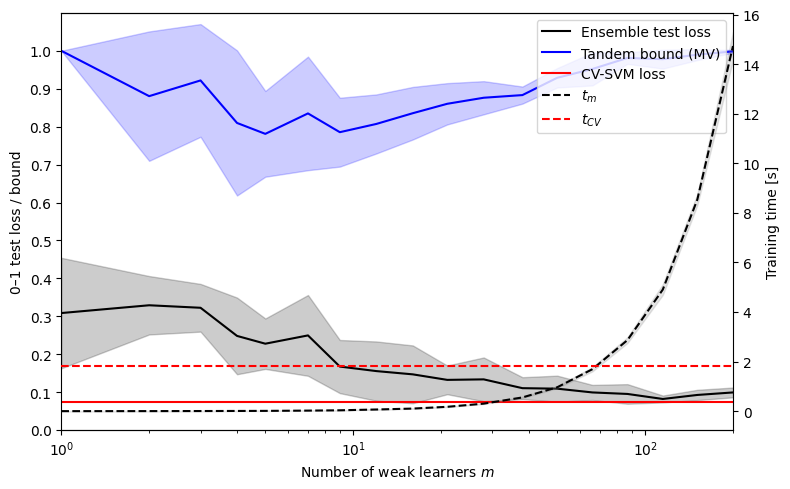

In [10]:
import time, math
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import zero_one_loss
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ───────── Config ───────── #
RANDOM_STATE = 0
TRAIN_SIZE   = 200
DELTA        = 0.05
MAX_ITERS    = 200
TOL          = 1e-6

# ─── Load & preprocess ───────────────────── #
df    = pd.read_csv("ionosphere.csv", header=None)
X_raw = df.iloc[:,:-1].values.astype(float)
y_raw = np.where(df.iloc[:,-1] == "g", 1, -1)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y_raw,
    train_size=TRAIN_SIZE,
    stratify=y_raw,
    random_state=RANDOM_STATE
)
scaler  = StandardScaler().fit(X_tr)
X_train = scaler.transform(X_tr)
X_test  = scaler.transform(X_te)
n, d    = X_train.shape
R       = d + 1
n_r     = n - R

# ─── γ grid (Jaakkola) ───────────────────── #
def jaakkola_gamma(X, y):
    mask  = y[:, None] != y[None, :]
    dists = np.linalg.norm(X[:, None, :] - X[None, :, :], axis=2)[mask]
    return 1.0 / (2.0 * np.median(dists)**2)

gamma_J    = jaakkola_gamma(X_train, y_tr)
gamma_grid = gamma_J * 10.0 ** np.arange(-4, 5)

# ─── Baseline CV‐SVM ─────────────────────── #
param_grid = {"C": 10.0**np.arange(-3, 4), "gamma": gamma_grid}
cv = GridSearchCV(
    SVC(kernel="rbf"), param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1
)
t0 = time.time()
cv.fit(X_train, y_tr)
t_cv    = time.time() - t0
cv_loss = zero_one_loss(y_te, cv.predict(X_test))

# ─── Helpers ─────────────────────────────── #
def pacbayes_rho(val_losses, lam):
    shift = val_losses.min()
    w     = np.exp(-lam * n_r * (val_losses - shift))
    return w / w.sum()

def pacbayes_lambda(E_val, kl_rho):
    num = 2.0 * n_r * E_val
    den = kl_rho + math.log(2.0 * math.sqrt(n_r) / DELTA)
    return 2.0 / (math.sqrt(1.0 + num/den) + 1.0)

# ─── Sweep & aggregate ───────────────────── #
M_VALUES = np.unique(np.round(np.logspace(0, math.log10(n), 20)).astype(int))
all_runs = []

for seed in range(10):
    rng    = np.random.default_rng(RANDOM_STATE + seed)
    run_rs = []
    for m in M_VALUES:
        # start timer for _this_ ensemble of size m
        t_start = time.time()

        # uniform prior over m models
        pi         = np.full(m, 1.0/m)
        val_losses = np.zeros(m)
        models     = []
        idx_va_list = []

        # train m weak RBF‐SVMs on random subsets
        for i in range(m):
            idx_tr = rng.choice(n, size=R, replace=False)
            idx_va = np.setdiff1d(np.arange(n), idx_tr)
            idx_va_list.append(idx_va)

            clf = SVC(kernel="rbf", C=1.0,
                      gamma=float(rng.choice(gamma_grid)))
            clf.fit(X_train[idx_tr], y_tr[idx_tr])
            models.append(clf)

            val_losses[i] = zero_one_loss(
                y_tr[idx_va],
                clf.predict(X_train[idx_va])
            )

        # alternating minimisation of PAC‐Bayes‐λ
        lam = max(1.0/math.sqrt(n_r), 0.5)
        for _ in range(MAX_ITERS):
            rho    = pacbayes_rho(val_losses, lam)
            E_val  = float(rho.dot(val_losses))
            kl_rho = float((rho * np.log(rho/pi)).sum())

            lam_n  = pacbayes_lambda(E_val, kl_rho)
            if abs(lam_n - lam) < TOL:
                lam = lam_n
                break
            lam = lam_n

        # majority‐vote test loss
        preds   = np.vstack([clf.predict(X_test) for clf in models]).T
        mv_loss = zero_one_loss(y_te, np.sign(preds.dot(rho)))

        # compute tandem bound
        pair_losses = np.zeros((m, m))
        overlaps    = np.zeros((m, m), dtype=int)
        for i in range(m):
            for j in range(i+1, m):
                idx_int = np.intersect1d(idx_va_list[i], idx_va_list[j])
                overlaps[i, j] = overlaps[j, i] = len(idx_int)
                if len(idx_int) > 0:
                    y_int = y_tr[idx_int]
                    e_i   = models[i].predict(X_train[idx_int]) != y_int
                    e_j   = models[j].predict(X_train[idx_int]) != y_int
                    pair_losses[i, j] = pair_losses[j, i] = np.mean(e_i & e_j)
        off = overlaps[np.triu_indices(m, k=1)]
        if off.size and off.min() > 0:
            n2         = off.min()
            exp_tandem = float(rho @ pair_losses @ rho)
            tandem_bnd = 4 * (
                exp_tandem/(1 - lam/2)
                + (2*kl_rho + math.log(2.0*math.sqrt(n2)/DELTA))
                  /(lam*(1 - lam/2)*n2)
            )
        else:
            tandem_bnd = 1.0

        # Clip the bound to [0, 1] for consistency with 0–1 loss
        tandem_bnd = min(tandem_bnd, 1.0)

        # record elapsed time for this m
        elapsed = time.time() - t_start
        run_rs.append((mv_loss, tandem_bnd, elapsed))

    all_runs.append(run_rs)

# aggregate
arr       = np.array(all_runs)
mean_mv   = arr[:, :, 0].mean(axis=0)
std_mv    = arr[:, :, 0].std(axis=0)
mean_tand = arr[:, :, 1].mean(axis=0)
std_tand  = arr[:, :, 1].std(axis=0)
mean_time = arr[:, :, 2].mean(axis=0)
std_time  = arr[:, :, 2].std(axis=0)

# ─── Print results ───────────────────────── #
print(f"{'m':>4s} | {'mv_loss':>8s} | {'±':^3s} | {'tandem_bnd':>10s} | {'±':^3s} | {'time[s]':>8s} | {'±':^3s}")
print("-"*80)
for m, ml, sl, tb, stb, mt, st in zip(
        M_VALUES, mean_mv, std_mv, mean_tand, std_tand, mean_time, std_time):
    print(f"{m:4d} | {ml:8.4f} | ± | {tb:10.4f} | ± | {stb:5.4f} | {mt:8.2f} | ± | {st:5.2f}")

print(f"\nCV-SVM baseline loss: {cv_loss:.4f}, time: {t_cv:.2f}s")

# ─── Plot ───────────────────────────────────── #
fig, ax1 = plt.subplots(figsize=(8,5))

# Left axis: loss & bounds
ax1.plot(M_VALUES, mean_mv,    'k-',  label='Ensemble test loss')
ax1.fill_between(M_VALUES, mean_mv - std_mv, mean_mv + std_mv, alpha=0.2, color='k')
ax1.plot(M_VALUES, mean_tand,  'b-',  label='Tandem bound (MV)')
ax1.fill_between(M_VALUES, mean_tand - std_tand, mean_tand + std_tand, alpha=0.2, color='b')
ax1.axhline(cv_loss, color='r', linestyle='-', label='CV-SVM loss')
ax1.set_xscale('log')
ax1.set_xlim(min(M_VALUES), max(M_VALUES))
ax1.margins(x=0)
ax1.set_ylim(0, 1.1)
ax1.set_yticks(np.linspace(0, 1, 11))
ax1.set_xlabel('Number of weak learners $m$')
ax1.set_ylabel('0–1 test loss / bound')
ax1.yaxis.set_label_position("left")
ax1.yaxis.tick_left()
ax1.spines['right'].set_visible(False)

# Right axis: timing
ax2 = ax1.twinx()
ax2.plot(M_VALUES, mean_time, 'k--', label='$t_m$')
ax2.fill_between(M_VALUES, mean_time - std_time, mean_time + std_time, alpha=0.2, color='gray')
ax2.axhline(t_cv, color='r', linestyle='--', label='$t_{CV}$')
ax2.set_ylabel('Training time [s]')
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
ax2.spines['left'].set_visible(False)

# Unified legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper right')

plt.tight_layout()
plt.savefig("ionosphere_tandem_agg.pdf", dpi=300)
plt.show()



## Corrected as noted by the notes

### main

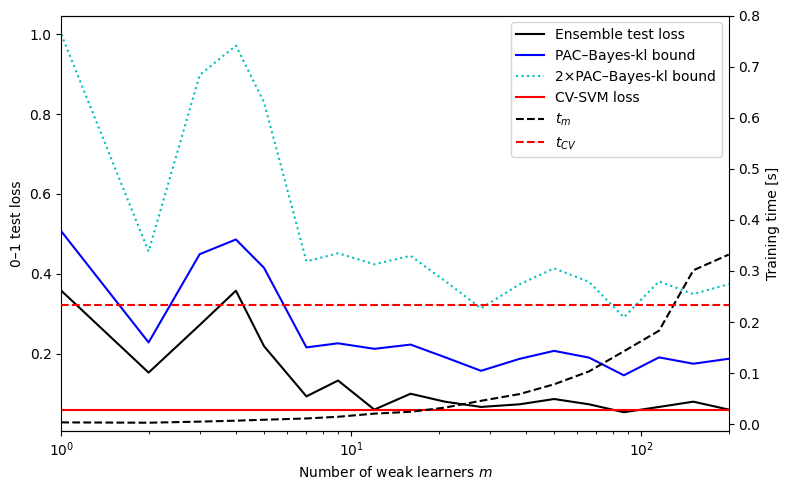

In [7]:
# ── Script 1: Single-seed PAC–Bayes with Corrected Bound (with time axis) ──

import time
import math
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.svm import SVC
from sklearn.metrics import zero_one_loss
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ───────── Configuration ───────── #
RANDOM_STATE = 3
TRAIN_SIZE   = 200
DELTA        = 0.05
MAX_ITERS    = 200
TOL          = 1e-6

# ─── Load & preprocess ───────────────────── #
df    = pd.read_csv("ionosphere.csv", header=None)
X_raw = df.iloc[:,:-1].values.astype(float)
y_raw = np.where(df.iloc[:,-1]=="g", 1, -1)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y_raw, train_size=TRAIN_SIZE,
    stratify=y_raw, random_state=RANDOM_STATE
)
scaler   = StandardScaler().fit(X_tr)
X_train  = scaler.transform(X_tr)
X_test   = scaler.transform(X_te)
n, d     = X_train.shape
R        = d + 1
n_r      = n - R

# ─── Jaakkola γ grid ───────────────────────── #
def jaakkola_gamma(X, y):
    mask  = y[:,None] != y[None,:]
    dists = np.linalg.norm(X[:,None,:] - X[None,:,:], axis=2)[mask]
    return 1.0 / (2.0 * np.median(dists)**2)
gamma_J    = jaakkola_gamma(X_train, y_tr)
gamma_grid = gamma_J * 10.0 ** np.arange(-4,5)

# ─── Baseline CV-SVM ───────────────────────── #
param_grid = {"C": 10.0**np.arange(-3,4), "gamma": gamma_grid}
cv = GridSearchCV(
    SVC(kernel="rbf"), param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1
)
t0 = time.time()
cv.fit(X_train, y_tr)
t_cv    = time.time() - t0
cv_loss = zero_one_loss(y_te, cv.predict(X_test))

# ─── PAC-Bayes helpers ─────────────────────── #
def kl_divergence(p, q):
    term1 = p * math.log(p/q) if p>0 else 0.0
    term2 = (1-p) * math.log((1-p)/(1-q)) if p<1 else 0.0
    return term1 + term2

def kl_inverse(p_hat, kl_term, n):
    if p_hat >= 1.0: return 1.0
    target = kl_term / n
    lo, hi  = p_hat, 1.0
    while hi - lo > 1e-12:
        mid = 0.5*(lo+hi)
        if kl_divergence(p_hat, mid) > target: hi = mid
        else: lo = mid
    return lo

def pacbayes_rho(val_losses, lam, n_r):
    shift = val_losses.min()
    w     = np.exp(-lam * n_r * (val_losses - shift))
    return w / w.sum()

def pacbayes_lambda(E_val, kl_rho, n_r, delta=DELTA):
    num = 2.0 * n_r * E_val
    den = kl_rho + math.log(2.0 * math.sqrt(n_r) / delta)
    return 2.0 / (math.sqrt(1.0 + num/den) + 1.0)

# ─── Sweep over m ──────────────────────────── #
M_VALUES = np.unique(np.round(np.logspace(0, math.log10(n), 20)).astype(int))
results  = []
rng      = np.random.default_rng(RANDOM_STATE)

for m in M_VALUES:
    t_start = time.time()
    pi      = np.full(m, 1.0/m)

    # train m weak SVMs
    val_losses = np.zeros(m)
    models     = []
    for i in range(m):
        idx_tr = rng.choice(n, size=R, replace=False)
        idx_va = np.setdiff1d(np.arange(n), idx_tr)
        clf    = SVC(kernel="rbf", C=1.0, gamma=float(rng.choice(gamma_grid)))
        clf.fit(X_train[idx_tr], y_tr[idx_tr])
        models.append(clf)
        val_losses[i] = zero_one_loss(y_tr[idx_va], clf.predict(X_train[idx_va]))

    # alternate rho/λ minimization
    lam = max(1.0/math.sqrt(n_r), 0.5)
    for _ in range(MAX_ITERS):
        rho    = pacbayes_rho(val_losses, lam, n_r)
        E_val  = float(rho.dot(val_losses))
        kl_rho = float((rho * np.log(rho/pi)).sum())
        lam_n  = pacbayes_lambda(E_val, kl_rho, n_r)
        if abs(lam_n - lam) < TOL: lam = lam_n; break
        lam = lam_n

    # majority-vote loss
    preds    = np.vstack([clf.predict(X_test) for clf in models]).T
    mv_loss  = zero_one_loss(y_te, np.sign(preds.dot(rho)))

    # randomized loss & bound
    single_losses = np.array([zero_one_loss(y_te, clf.predict(X_test)) for clf in models])
    rnd_loss = float(rho.dot(single_losses))
    kl_term  = kl_rho + math.log(2.0 * math.sqrt(n_r)/DELTA)
    rnd_bound= kl_inverse(E_val, kl_term, n_r)
    mv_bound = min(1.0, 2.0 * rnd_bound)

    results.append((m, mv_loss, rnd_loss, rnd_bound, mv_bound, time.time()-t_start))

# ─── Plot ───────────────────────────────────── #
ms, mv_losses, rnd_losses, rnd_bounds, mv_bounds, times = zip(*results)


# ─── Plot ─────────────────────────────────────── #
fig, ax1 = plt.subplots(figsize=(8,5))

# --- Left axis: loss curves ---
ax1.plot(ms, mv_losses, 'k-',  label='Ensemble test loss')
ax1.plot(ms, rnd_bounds, 'b-',  label='PAC–Bayes-kl bound')
ax1.plot(ms, mv_bounds,  'c:',  label='2×PAC–Bayes-kl bound')
ax1.axhline(cv_loss, color='r', linestyle='-', label='CV-SVM loss')

ax1.set_xscale('log')
ax1.set_xlim(min(ms), max(ms))
ax1.margins(x=0)
# ax1.set_yticks(np.arange(0.0, 0.60, 0.05))
ax1.set_xlabel('Number of weak learners $m$')
ax1.set_ylabel('0–1 test loss')
ax1.yaxis.set_label_position("left")
ax1.yaxis.tick_left()
ax1.spines['right'].set_visible(False)

# --- Right axis: timing ---
ax2 = ax1.twinx()
ax2.plot(ms, times,     'k--', label='$t_m$')
ax2.axhline(t_cv, color='r', linestyle='--', label='$t_{CV}$')

# ax2.set_ylim(0.0, 0.8)
ax2.set_yticks(np.arange(0.0, 0.9, 0.1))
ax2.set_ylabel('Training time [s]')
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
ax2.spines['left'].set_visible(False)

# --- Unified legend ---
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper right')

plt.tight_layout()
plt.savefig("ionosphere_corrected_single.pdf", dpi=300)
plt.show()


### ten aggregated runs

   m |  MV loss |  ±  |  Rnd loss |  ±  |  PB-kl |  ±  |  2×PB |  ±  |  Time[s] |  ± 
------------------------------------------------------------------------------------------
   1 |   0.3364 | ± | 0.0573 |    0.3364 | ± | 0.0573 | 0.4763 | ± | 0.0531 | 0.9449 | ± | 0.1017 |     0.00 | ± |  0.00
   2 |   0.3225 | ± | 0.0715 |    0.3225 | ± | 0.0714 | 0.4598 | ± | 0.0850 | 0.9127 | ± | 0.1661 |     0.00 | ± |  0.00
   3 |   0.2781 | ± | 0.0956 |    0.2786 | ± | 0.0953 | 0.4251 | ± | 0.0872 | 0.8483 | ± | 0.1727 |     0.00 | ± |  0.00
   4 |   0.2146 | ± | 0.1239 |    0.2139 | ± | 0.1222 | 0.3625 | ± | 0.1174 | 0.7251 | ± | 0.2347 |     0.01 | ± |  0.00
   5 |   0.2126 | ± | 0.0965 |    0.2129 | ± | 0.0967 | 0.3501 | ± | 0.1021 | 0.7001 | ± | 0.2041 |     0.01 | ± |  0.00
   7 |   0.1742 | ± | 0.1015 |    0.1740 | ± | 0.1011 | 0.3227 | ± | 0.1004 | 0.6453 | ± | 0.2007 |     0.01 | ± |  0.00
   9 |   0.1225 | ± | 0.0509 |    0.1246 | ± | 0.0544 | 0.2717 | ± | 0.0826 | 0.5435 | ± | 0.1652

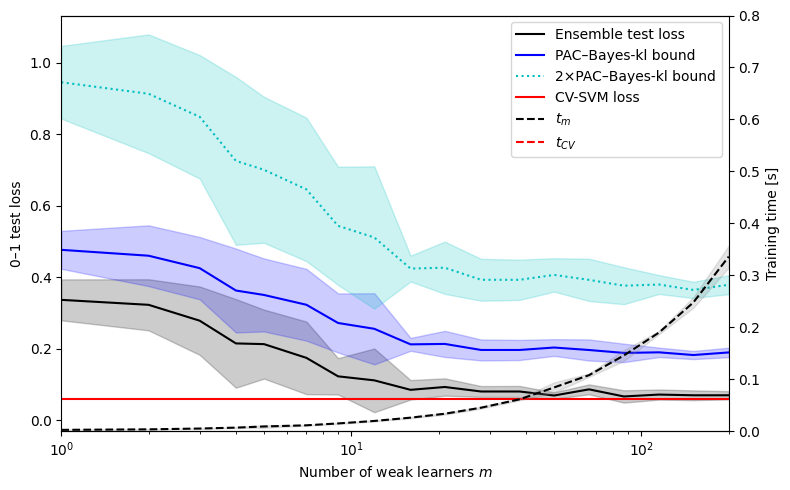

In [6]:
import time, math
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.svm import SVC
from sklearn.metrics import zero_one_loss
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ───────── Configuration ───────── #
RANDOM_STATE = 3
TRAIN_SIZE   = 200
DELTA        = 0.05
MAX_ITERS    = 200
TOL          = 1e-6

# ─── Load & preprocess ───────────────────── #
df    = pd.read_csv("ionosphere.csv", header=None)
X_raw = df.iloc[:,:-1].values.astype(float)
y_raw = np.where(df.iloc[:,-1]=="g", 1, -1)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y_raw, train_size=TRAIN_SIZE,
    stratify=y_raw, random_state=RANDOM_STATE
)
scaler   = StandardScaler().fit(X_tr)
X_train  = scaler.transform(X_tr)
X_test   = scaler.transform(X_te)
n, d     = X_train.shape
R        = d + 1
n_r      = n - R

# ─── Jaakkola γ grid ───────────────────────── #
def jaakkola_gamma(X, y):
    mask  = y[:,None] != y[None,:]
    dists = np.linalg.norm(X[:,None,:] - X[None,:,:], axis=2)[mask]
    return 1.0 / (2.0 * np.median(dists)**2)
gamma_J    = jaakkola_gamma(X_train, y_tr)
gamma_grid = gamma_J * 10.0 ** np.arange(-4,5)

# ─── Baseline CV-SVM ───────────────────────── #
param_grid = {"C":10.0**np.arange(-3,4), "gamma":gamma_grid}
cv = GridSearchCV(
    SVC(kernel="rbf"),
    param_grid,
    cv=StratifiedKFold(5,shuffle=True,random_state=RANDOM_STATE),
    n_jobs=-1
)
t0 = time.time()
cv.fit(X_train, y_tr)
t_cv    = time.time() - t0
cv_loss = zero_one_loss(y_te, cv.predict(X_test))

# ─── PAC-Bayes helpers ─────────────────────── #
def kl_divergence(p,q):
    t1 = p*math.log(p/q) if p>0 else 0.0
    t2 = (1-p)*math.log((1-p)/(1-q)) if p<1 else 0.0
    return t1+t2

def kl_inverse(p_hat,kl_term,n):
    if p_hat>=1.0: return 1.0
    target=kl_term/n; lo,hi=p_hat,1.0
    while hi-lo>1e-12:
        mid=0.5*(lo+hi)
        if kl_divergence(p_hat,mid)>target: hi=mid
        else: lo=mid
    return lo

def pacbayes_rho(val_losses,lam,n_r):
    shift=val_losses.min()
    w=np.exp(-lam*n_r*(val_losses-shift))
    return w/w.sum()

def pacbayes_lambda(E_val,kl_rho,n_r,delta=DELTA):
    num=2.0*n_r*E_val
    den=kl_rho+math.log(2.0*math.sqrt(n_r)/delta)
    return 2.0/(math.sqrt(1.0+num/den)+1.0)

# ─── Sweep & aggregate ────────────────────── #
M_VALUES = np.unique(np.round(np.logspace(0,math.log10(n),20)).astype(int))
all_runs = []

for seed in range(10):
    rng = np.random.default_rng(RANDOM_STATE + seed)
    run_results = []
    for m in M_VALUES:
        t_start = time.time()
        pi = np.full(m,1.0/m)

        # train m weak SVMs
        val_losses, models = np.zeros(m), []
        for i in range(m):
            idx_tr = rng.choice(n,size=R,replace=False)
            idx_va = np.setdiff1d(np.arange(n), idx_tr)
            clf = SVC(kernel="rbf",C=1.0,gamma=float(rng.choice(gamma_grid)))
            clf.fit(X_train[idx_tr], y_tr[idx_tr])
            models.append(clf)
            val_losses[i] = zero_one_loss(y_tr[idx_va], clf.predict(X_train[idx_va]))

        # alternate
        lam = max(1.0/math.sqrt(n_r), 0.5)
        for _ in range(MAX_ITERS):
            rho    = pacbayes_rho(val_losses,lam,n_r)
            E_val  = float(rho.dot(val_losses))
            kl_rho = float((rho*np.log(rho/pi)).sum())
            lam_n  = pacbayes_lambda(E_val,kl_rho,n_r)
            if abs(lam_n-lam)<TOL: lam=lam_n; break
            lam=lam_n

        # compute metrics
        preds    = np.vstack([clf.predict(X_test) for clf in models]).T
        mv_loss  = zero_one_loss(y_te, np.sign(preds.dot(rho)))
        single_losses = np.array([zero_one_loss(y_te,clf.predict(X_test)) for clf in models])
        rnd_loss = float(rho.dot(single_losses))
        kl_term  = kl_rho+math.log(2.0*math.sqrt(n_r)/DELTA)
        rnd_bound= kl_inverse(E_val,kl_term,n_r)
        mv_bound = min(1.0,2.0*rnd_bound)
        elapsed  = time.time() - t_start

        run_results.append((m, mv_loss, rnd_loss, rnd_bound, mv_bound, elapsed))
    all_runs.append(run_results)

# ─── Aggregate metrics ─────────────────────── #
arr        = np.array(all_runs)
ms         = M_VALUES
mv_losses  = arr[:,:,1]
rnd_losses = arr[:,:,2]
rnd_bounds = arr[:,:,3]
mv_bounds  = arr[:,:,4]
times      = arr[:,:,5]

mean_mv, std_mv   = mv_losses.mean(axis=0), mv_losses.std(axis=0)
mean_rnd, std_rnd = rnd_losses.mean(axis=0), rnd_losses.std(axis=0)
mean_rb, std_rb   = rnd_bounds.mean(axis=0), rnd_bounds.std(axis=0)
mean_mb, std_mb   = mv_bounds.mean(axis=0), mv_bounds.std(axis=0)
mean_time, std_time = times.mean(axis=0), times.std(axis=0)

# ─── Print mean±std table ──────────────────── #
print(f"{'m':>4s} | {'MV loss':>8s} | {'±':^3s} | {'Rnd loss':>9s} | {'±':^3s} | "
      f"{'PB-kl':>6s} | {'±':^3s} | {'2×PB':>5s} | {'±':^3s} | {'Time[s]':>8s} | {'±':^3s}")
print("-"*90)
for i, m in enumerate(ms):
    print(f"{m:4d} | "
          f"{mean_mv[i]:8.4f} | ± | {std_mv[i]:5.4f} | "
          f"{mean_rnd[i]:9.4f} | ± | {std_rnd[i]:5.4f} | "
          f"{mean_rb[i]:6.4f} | ± | {std_rb[i]:4.4f} | "
          f"{mean_mb[i]:5.4f} | ± | {std_mb[i]:4.4f} | "
          f"{mean_time[i]:8.2f} | ± | {std_time[i]:5.2f}")

# ─── Plot ───────────────────────────────────── #
fig, ax1 = plt.subplots(figsize=(8,5))

# --- Left axis: loss curves ---
ax1.plot(ms, mean_mv,    'k-',  label='Ensemble test loss')
ax1.fill_between(ms, mean_mv - std_mv, mean_mv + std_mv, alpha=0.2, color='k')

ax1.plot(ms, mean_rb,    'b-',  label='PAC–Bayes-kl bound')
ax1.fill_between(ms, mean_rb - std_rb, mean_rb + std_rb, alpha=0.2, color='b')

ax1.plot(ms, mean_mb,    'c:',  label='2×PAC–Bayes-kl bound')
ax1.fill_between(ms, mean_mb - std_mb, mean_mb + std_mb, alpha=0.2, color='c')

ax1.axhline(cv_loss, color='r', linestyle='-', label='CV-SVM loss')

ax1.set_xscale('log')
ax1.set_xlim(min(ms), max(ms))
ax1.margins(x=0)
ax1.set_xlabel('Number of weak learners $m$')

# ax1.set_ylim(0.0, 0.55)
# ax1.set_yticks(np.arange(0.0, 0.60, 0.05))
ax1.set_ylabel('0–1 test loss')
ax1.yaxis.set_label_position("left")
ax1.yaxis.tick_left()
ax1.spines['right'].set_visible(False)


# --- Right axis: timing ---
ax2 = ax1.twinx()
ax2.plot(ms, mean_time,  'k--', label='$t_m$')
ax2.fill_between(ms, mean_time - std_time, mean_time + std_time, alpha=0.2, color='gray')

ax2.axhline(t_cv, color='r', linestyle='--', label='$t_{CV}$')

ax2.set_ylim(0.0, max(mean_time + std_time) * 1.1)
ax2.set_yticks(np.arange(0.0, 0.9, 0.1))
ax2.set_ylabel('Training time [s]')
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
ax2.spines['left'].set_visible(False)


# --- Unified legend ---
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper right')

plt.tight_layout()
plt.savefig("ionosphere_corrected_aggregate.pdf", dpi=300)
plt.show()


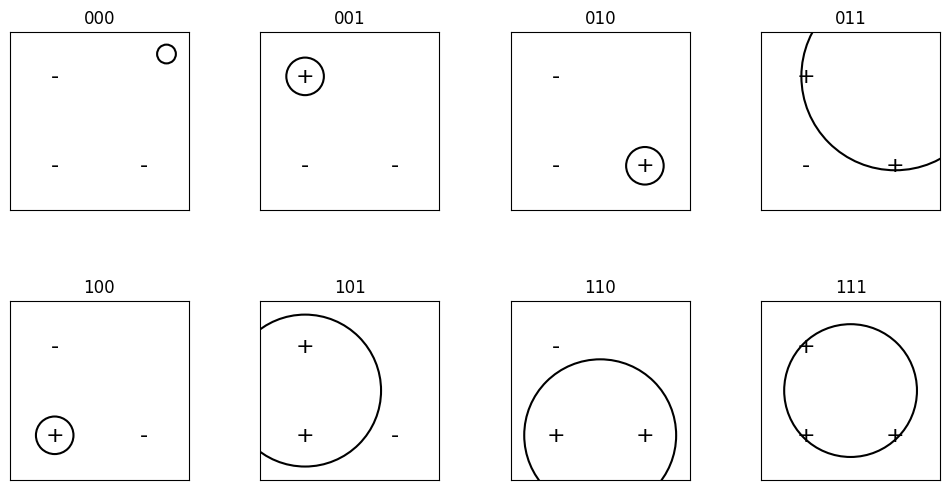

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Define three noncollinear points
points = np.array([
    (0.0, 0.0),  # x0
    (1.0, 0.0),  # x1
    (0.0, 1.0)   # x2
])

# All 8 possible labelings
labelings = [list(map(int, f"{i:03b}")) for i in range(8)]

# Plot layout: 2 rows x 4 columns
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
plt.subplots_adjust(wspace=0.4, hspace=0.4)

for ax, vector in zip(axes.flat, labelings):
    k = sum(vector)

    if k == 0:
        # move tiny circle into visible area
        center, radius = (1.25, 1.25), 0.1

    elif k == 3:
        # circumcircle through all three
        A, B, C = points
        D = 2 * (
            A[0]*(B[1]-C[1]) +
            B[0]*(C[1]-A[1]) +
            C[0]*(A[1]-B[1])
        )
        a2, b2, c2 = A.dot(A), B.dot(B), C.dot(C)
        ux = (a2*(B[1]-C[1]) + b2*(C[1]-A[1]) + c2*(A[1]-B[1])) / D
        uy = (a2*(C[0]-B[0]) + b2*(A[0]-C[0]) + c2*(B[0]-A[0])) / D
        center = np.array([ux, uy])
        radius = np.linalg.norm(center - A)

    elif k == 1:
        # circle centered at the single positive
        idx = vector.index(1)
        center = points[idx]
        radius = 0.2

    else:
        # k == 2: except 011, use your original 2-point logic
        if vector == [0, 1, 1]:
            # special: big circle around (1,0) & (0,1), exclude (0,0)
            center = np.array([1.0, 1.0])
            # radius = max(dist to each positive)
            pos_pts = points[[1, 2]]
            radius = max(np.linalg.norm(center - p) for p in pos_pts)
        else:
            # original midpoint-based tweak
            idxs = [i for i, v in enumerate(vector) if v == 1]
            p0, p1 = points[idxs[0]], points[idxs[1]]
            m = (p0 + p1) / 2
            r0 = np.linalg.norm(p0 - p1) / 2
            other = points[[i for i in range(3) if vector[i] == 0][0]]
            diff = np.linalg.norm(other - m) - r0
            radius = r0 + np.sign(diff) * (abs(diff) / 2)
            center = m

    # ensure strict inclusion
    radius *= 1.05

    # draw
    ax.add_patch(Circle(center, radius, fill=False, linewidth=1.5))
    for i, pt in enumerate(points):
        symbol = '+' if vector[i] == 1 else '-'
        ax.text(pt[0], pt[1], symbol, fontsize=16, ha='center', va='center')

    ax.set_aspect('equal', 'box')
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(''.join(map(str, vector)), fontsize=12)

plt.show()


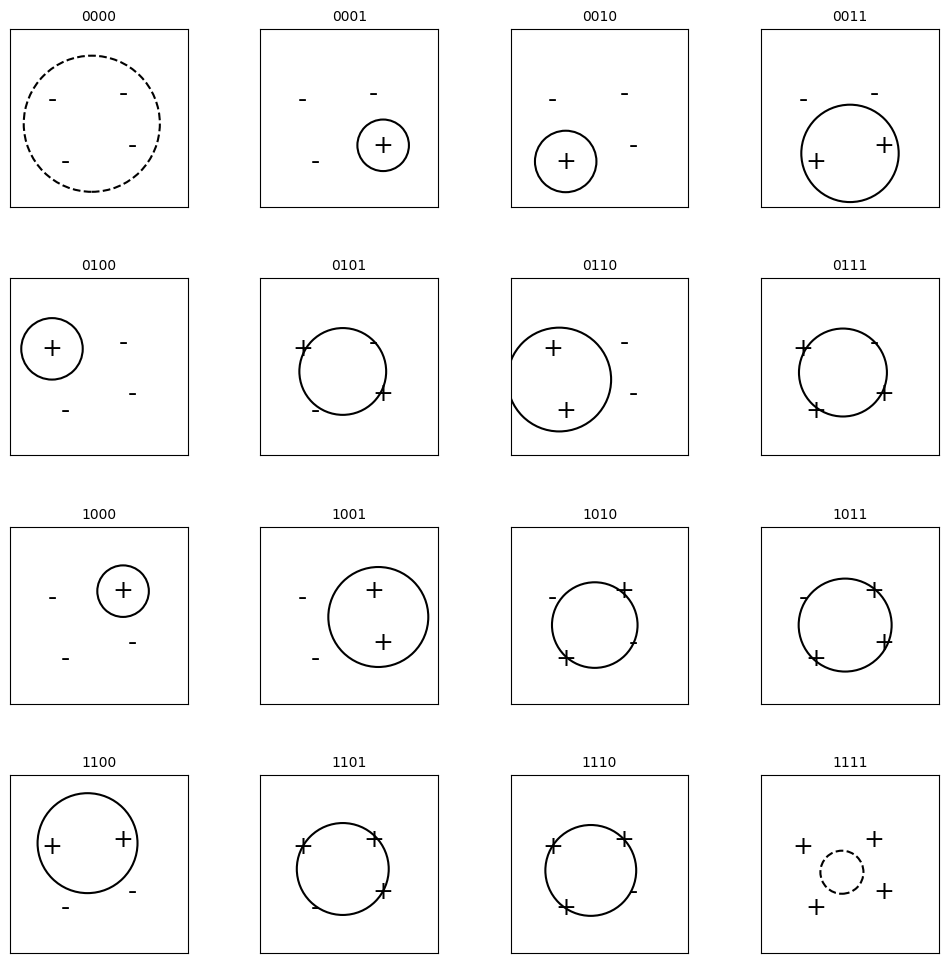

In [8]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# -----------------------------------------------------------------------------
# Minimal enclosing circle (Welzl’s algorithm) by Nayuki (public domain).
# https://www.nayuki.io/page/smallest-enclosing-circle
# -----------------------------------------------------------------------------
def _circle_from(p, q, r):
    ax, ay = p; bx, by = q; cx, cy = r
    d = 2*(ax*(by-cy) + bx*(cy-ay) + cx*(ay-by))
    if abs(d) < 1e-12:
        return None
    ux = ((ax*ax+ay*ay)*(by-cy) + (bx*bx+by*by)*(cy-ay) + (cx*cx+cy*cy)*(ay-by)) / d
    uy = ((ax*ax+ay*ay)*(cx-bx) + (bx*bx+by*by)*(ax-cx) + (cx*cx+cy*cy)*(bx-ax)) / d
    center = (ux, uy)
    radius = math.hypot(ux-ax, uy-ay)
    return (center, radius)

def _circle_from_2(p, q):
    center = ((p[0]+q[0])/2.0, (p[1]+q[1])/2.0)
    radius = math.hypot(center[0]-p[0], center[1]-p[1])
    return (center, radius)

def _is_in_circle(circ, p):
    (cx, cy), r = circ
    return math.hypot(p[0]-cx, p[1]-cy) <= r + 1e-12

def _welzl(points, boundary):
    if not points or len(boundary) == 3:
        # Base case: trivial circle on boundary
        if len(boundary) == 0:
            return ((0,0), 0)
        if len(boundary) == 1:
            return (boundary[0], 0)
        if len(boundary) == 2:
            return _circle_from_2(boundary[0], boundary[1])
        return _circle_from(boundary[0], boundary[1], boundary[2])
    p = points.pop()
    circ = _welzl(points, boundary)
    if _is_in_circle(circ, p):
        points.append(p)
        return circ
    boundary.append(p)
    circ = _welzl(points, boundary)
    boundary.pop()
    points.append(p)
    return circ

def min_enclosing_circle(points):
    pts = points.copy()
    random.shuffle(pts)
    return _welzl(pts, [])

# -----------------------------------------------------------------------------
# Main plotting
# -----------------------------------------------------------------------------
# Four points in strictly convex position
points = np.array([
    (1.0,  1.0),
    (-1.2, 0.8),
    (-0.8, -1.1),
    (1.3, -0.6)
])

# All 16 original labelings: bit '1'='+', '0'='–'
labelings = [list(map(int, f"{i:04b}")) for i in range(16)]

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
plt.subplots_adjust(wspace=0.4, hspace=0.4)

for ax, orig in zip(axes.flat, labelings):
    # Determine positive vs negative disk
    s = sum(orig)
    neg = (s == 0 or s == 4)

    # Select the target set S (positives for pos‐disk, negatives for neg‐disk)
    if neg:
        S = [tuple(points[i]) for i,bit in enumerate(orig) if bit==0]
        Ex = [tuple(points[i]) for i,bit in enumerate(orig) if bit==1]
    else:
        S = [tuple(points[i]) for i,bit in enumerate(orig) if bit==1]
        Ex = [tuple(points[i]) for i,bit in enumerate(orig) if bit==0]

    # Compute minimum enclosing circle of S
    (cx, cy), r_min = min_enclosing_circle(S)

    # Compute r_max = distance from center to nearest excluded point
    if Ex:
        dists = [math.hypot(q[0]-cx, q[1]-cy) for q in Ex]
        r_max = min(dists)
    else:
        # If no excluded points, make a big circle around centroid
        r_max = max(math.hypot(p[0]-cx, p[1]-cy) for p in points) * 2

    # Pick radius halfway in the safe zone, then slightly shrink for white space
    r = (r_min + 0.5*(r_max - r_min)) * 0.98

    # Draw circle: solid for positive, dashed for negative
    style = {'linewidth':1.5, 'linestyle':'--'} if neg else {'linewidth':1.5}
    ax.add_patch(Circle((cx,cy), r, fill=False, **style))

    # Annotate with the ORIGINAL labels
    for i, pt in enumerate(points):
        sym = '+' if orig[i]==1 else '-'
        ax.text(pt[0], pt[1], sym, fontsize=18, ha='center', va='center')

    ax.set_aspect('equal', 'box')
    ax.set_xlim(-2.5, 3)
    ax.set_ylim(-2.5, 3)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(''.join(map(str, orig)), fontsize=10)

plt.show()


## Empirical proof of GP equivalence for 1D Spectral Circulant

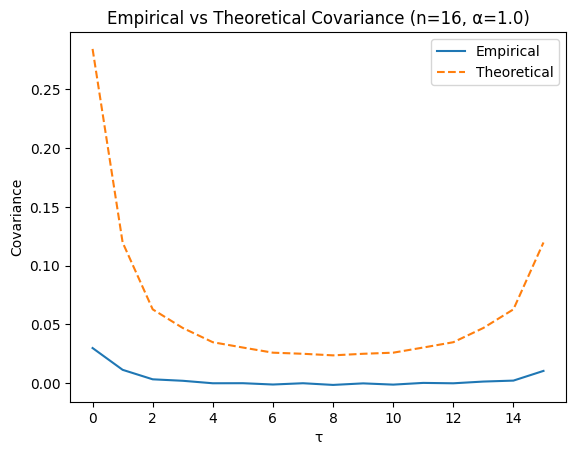

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n = 16
alpha = 1.0
M = 5000

# Precompute sigma^2
sigma2 = np.array([(1 + (k if k <= n/2 else n-k)**alpha)**-1 for k in range(n)])

# Generate samples and empirical covariance
emp_cov = np.zeros(n)
for m in range(M):
    # Generate Fourier coefficients with Hermitian symmetry
    F = np.zeros(n, dtype=complex)
    # k = 0
    F[0] = np.random.normal(0, np.sqrt(sigma2[0]))
    # k = 1 to n/2-1
    for k in range(1, n//2):
        a = np.random.normal(0, np.sqrt(sigma2[k]))
        b = np.random.normal(0, np.sqrt(sigma2[k]))
        F[k] = a + 1j*b
        F[n-k] = np.conj(F[k])
    # k = n/2 if even
    if n % 2 == 0:
        F[n//2] = np.random.normal(0, np.sqrt(sigma2[n//2]))
    
    # Inverse FFT
    f = np.fft.ifft(F).real
    
    # Accumulate covariance with f[0]
    emp_cov += f[0] * f

emp_cov /= M

# Theoretical covariance
k = np.arange(n)
theo_cov = np.real(1/n * np.sum(sigma2[:, None] * np.exp(2j * np.pi * k[:, None] * np.arange(n) / n), axis=0))

# Plotting
plt.figure()
plt.plot(range(n), emp_cov, label='Empirical')
plt.plot(range(n), theo_cov, linestyle='--', label='Theoretical')
plt.xlabel('τ')
plt.ylabel('Covariance')
plt.title(f'Empirical vs Theoretical Covariance (n={n}, α={alpha})')
plt.legend()
plt.show()
